# Global Markets + VIX → India First Hour  (v2)
**New vs v1:** US VIX · India VIX · VSTOXX · prev-day India return · sign-corrected composite · percentile thresholds · matplotlib only · 15 cells

In [1]:
# Cell 2 — Imports + Config
# !pip install kiteconnect yfinance scipy pytz pandas numpy matplotlib requests

import os, time, pickle, warnings, requests
from datetime import date, timedelta, datetime
from calendar import month_abbr

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import yfinance as yf
from kiteconnect import KiteConnect
import pytz

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)

# Paths — works regardless of where Jupyter is launched from
BASE      = os.path.abspath(os.path.dirname('v2_india_global.ipynb')) or os.getcwd()
CACHE_DIR = os.path.join(BASE, 'cache')
KITE_DIR  = os.path.join(BASE, 'kite_minute_cache')
os.makedirs(CACHE_DIR, exist_ok=True)
os.makedirs(KITE_DIR,  exist_ok=True)

# ── Zerodha credentials (from your Kite Connect app dashboard) ────────────────
# ── Zerodha Kite credentials (loaded from .env, never hardcoded) ────────
from pathlib import Path as _P
_env = _P("..") / ".env"   # .env is one level up in market-research/
API_KEY, API_SECRET = None, None
if _env.exists():
    for _l in _env.read_text().splitlines():
        if _l.strip().lower().startswith("api_key"):
            API_KEY    = _l.split("=", 1)[1].strip()
        elif _l.strip().lower().startswith("api_secret"):
            API_SECRET = _l.split("=", 1)[1].strip()
if not API_KEY or not API_SECRET:
    raise EnvironmentError(f"api_key/api_secret not found in {_env.resolve()}")

END_DATE    = date.today()
START_DATE  = END_DATE - timedelta(days=3*365 + 5)
NIFTY_TOKEN = 256265      # NSE:NIFTY 50 index token — verify with Cell 3 if needed
GAP_THRESHOLD = 0.0015    # 0.15% minimum to classify as gap-up / gap-down

PRICE_TICKERS = {
    'SP500'   : '^GSPC',   # S&P 500
    'NASDAQ'  : '^IXIC',   # NASDAQ Composite
    'DOW'     : '^DJI',    # Dow Jones
    'NIKKEI'  : '^N225',   # Nikkei 225
    'DAX'     : '^GDAXI',  # DAX (Germany)
    'HANGSENG': '^HSI',    # Hang Seng
    'FTSE'    : '^FTSE',   # FTSE 100 (UK)
    'SGX'     : 'NKD=F',   # Nikkei USD Futures — SGX Nifty proxy
}
VIX_TICKERS = {
    'VIX_US': '^VIX',    # CBOE VIX (US fear gauge)
    'VIX_EU': '^V2TX',   # VSTOXX (Europe fear gauge) — may be unavailable
}

print(f'Period  : {START_DATE}  to  {END_DATE}')
print(f'Cache   : {CACHE_DIR}')
print(f'Kite    : {KITE_DIR}')


Period  : 2023-03-30  to  2026-04-03
Cache   : c:\Users\sayan\OneDrive\Desktop\Projects\03_Market_Research\market-research\v2\cache
Kite    : c:\Users\sayan\OneDrive\Desktop\Projects\03_Market_Research\market-research\v2\kite_minute_cache


In [ ]:
# Cell 3 — Kite authentication
# ─────────────────────────────────────────────────────────────────────────────
# HOW TO LOGIN (do this once per day — Kite tokens expire at midnight IST):
#
#   STEP 1: Run this cell → copy the login URL printed below
#   STEP 2: Open URL in browser → login with Zerodha credentials
#   STEP 3: After redirect, copy the request_token from the URL bar:
#             https://127.0.0.1/?request_token=XXXXX&action=login&status=success
#   STEP 4: Paste token below, uncomment the 3 lines, re-run this cell
#   STEP 5: Comment those 3 lines out again (don't leave live tokens in notebooks)
# ─────────────────────────────────────────────────────────────────────────────

kite = KiteConnect(api_key=API_KEY)
print('Login URL:')
print(kite.login_url())
print()

# REQUEST_TOKEN = 'jlW983co2XEtP06vFy157Y7hQW6mRqch'
# sess = kite.generate_session(REQUEST_TOKEN, api_secret=API_SECRET)
# open(os.path.join(CACHE_DIR, 'access_token.txt'), 'w').write(sess['access_token'])

# ── Load saved token (works for the rest of the day) ─────────────────────────
tok_path = os.path.join(CACHE_DIR, 'access_token.txt')
if os.path.exists(tok_path):
    kite.set_access_token(open(tok_path).read().strip())
    try:
        print('Logged in as:', kite.profile()['user_name'])
    except Exception as e:
        print(f'Token load failed ({e}) — re-run STEP 4 above.')
else:
    print('No saved token — complete login steps above first.')


Login URL:
https://kite.zerodha.com/connect/login?api_key=vobx4ih6afnkqiaq&v=3

Logged in as: Sayan Chaudhuri


In [5]:
# Cell 4 — Fetch global price + VIX data (yfinance, cached)

def yf_load(tickers_dict, label):
    cache = os.path.join(CACHE_DIR, f'{label}.pkl')
    if os.path.exists(cache):
        print(f'  [{label}] from cache')
        return pickle.load(open(cache,'rb'))
    result = {}
    for name, ticker in tickers_dict.items():
        try:
            df = yf.download(ticker, start=str(START_DATE-timedelta(days=10)),
                             end=str(END_DATE+timedelta(days=2)),
                             auto_adjust=True, progress=False)
            if isinstance(df.columns, pd.MultiIndex):
                df.columns = df.columns.get_level_values(0)
            df.index = pd.to_datetime(df.index).date
            result[name] = df
            print(f'    {name:12s} {len(df)} rows')
        except Exception as e:
            print(f'    {name:12s} ERROR: {e}')
    pickle.dump(result, open(cache,'wb'))
    return result

price_data = yf_load(PRICE_TICKERS, 'price_data')
vix_data   = yf_load(VIX_TICKERS,   'vix_data')

nifty_cache = os.path.join(CACHE_DIR, 'nifty_daily.pkl')
if os.path.exists(nifty_cache):
    nifty_daily = pickle.load(open(nifty_cache,'rb'))
    print('  nifty_daily from cache')
else:
    nifty_daily = yf.download('^NSEI', start=str(START_DATE-timedelta(days=15)),
                              end=str(END_DATE+timedelta(days=2)),
                              auto_adjust=True, progress=False)
    if isinstance(nifty_daily.columns, pd.MultiIndex):
        nifty_daily.columns = nifty_daily.columns.get_level_values(0)
    nifty_daily.index = pd.to_datetime(nifty_daily.index).date
    pickle.dump(nifty_daily, open(nifty_cache,'wb'))
    print(f'  nifty_daily: {len(nifty_daily)} rows')


  [price_data] from cache
  [vix_data] from cache
  nifty_daily from cache


In [6]:
# Cell 5 — India VIX via yfinance (^INDIAVIX), cached

def fetch_india_vix():
    cache = os.path.join(CACHE_DIR, 'india_vix.csv')
    if os.path.exists(cache):
        df = pd.read_csv(cache, index_col=0, parse_dates=True)
        df.index = pd.to_datetime(df.index).date
        print(f'  India VIX: {len(df)} rows from cache')
        return df
    print('  Fetching ^INDIAVIX via yfinance...')
    raw = yf.download('^INDIAVIX',
                      start=str(START_DATE - timedelta(days=10)),
                      end=str(END_DATE + timedelta(days=2)),
                      auto_adjust=True, progress=False)
    if isinstance(raw.columns, pd.MultiIndex):
        raw.columns = raw.columns.get_level_values(0)
    if raw.empty:
        print('  WARNING: no data returned.')
        return pd.DataFrame()
    df = raw[['Open','High','Low','Close']].copy()
    df.columns = ['vix_open','vix_high','vix_low','vix_close']
    df.index = pd.to_datetime(df.index).date
    df = df[df['vix_close'] > 0].sort_index()
    df.to_csv(cache)
    print(f'  India VIX: {len(df)} rows  ({df.index.min()} to {df.index.max()})')
    return df

india_vix = fetch_india_vix()
if not india_vix.empty:
    print(india_vix['vix_close'].describe().round(2))


  India VIX: 741 rows from cache
count   741.0000
mean     13.5800
std       2.8700
min       9.1500
25%      11.6300
50%      13.0400
75%      14.5900
max      27.8900
Name: vix_close, dtype: float64


In [7]:
# Cell 6 — Load NIFTY 50 minute data from Kite (59-day chunks, cached)

def kite_minutes(token, start, end):
    frames = []
    cur = start
    while cur <= end:
        nxt  = min(cur + timedelta(days=58), end)
        path = os.path.join(KITE_DIR, f'minute_{token}_{cur}_{nxt}.pkl')
        if os.path.exists(path):
            df = pd.read_pickle(path)
        else:
            print(f'  API {cur} -> {nxt}...', end=' ')
            try:
                recs = kite.historical_data(token,
                    from_date=datetime.combine(cur, datetime.min.time()),
                    to_date  =datetime.combine(nxt, datetime.strptime('23:59:59','%H:%M:%S').time()),
                    interval='minute', continuous=False, oi=False)
                df = pd.DataFrame(recs) if recs else pd.DataFrame()
                if not df.empty:
                    df['date'] = pd.to_datetime(df['date'])
                    df = df.set_index('date').sort_index()
                df.to_pickle(path)
                print(f'{len(df)} rows')
                time.sleep(0.5)
            except Exception as e:
                print(f'ERROR {e}'); df = pd.DataFrame()
        if not df.empty: frames.append(df)
        cur = nxt + timedelta(days=1)
    if not frames: return pd.DataFrame()
    out = pd.concat(frames).sort_index()
    return out[~out.index.duplicated(keep='first')]

print('Loading NIFTY minute data...')
minute_raw = kite_minutes(NIFTY_TOKEN, START_DATE, END_DATE)
print(f'{len(minute_raw):,} rows  |  {minute_raw.index.min()} -> {minute_raw.index.max()}')


Loading NIFTY minute data...
  API 2023-03-30 -> 2023-05-27... 13875 rows
  API 2023-05-28 -> 2023-07-25... 15363 rows
  API 2023-07-26 -> 2023-09-22... 15374 rows
  API 2023-09-23 -> 2023-11-20... 14310 rows
  API 2023-11-21 -> 2024-01-18... 15375 rows
  API 2024-01-19 -> 2024-03-17... 14730 rows
  API 2024-03-18 -> 2024-05-15... 14244 rows
  API 2024-05-16 -> 2024-07-13... 15105 rows
  API 2024-07-14 -> 2024-09-10... 15000 rows
  API 2024-09-11 -> 2024-11-08... 15435 rows
  API 2024-11-09 -> 2025-01-06... 14250 rows
  API 2025-01-07 -> 2025-03-06... 16125 rows
  API 2025-03-07 -> 2025-05-04... 13125 rows
  API 2025-05-05 -> 2025-07-02... 16125 rows
  API 2025-07-03 -> 2025-08-30... 15000 rows
  API 2025-08-31 -> 2025-10-28... 14685 rows
  API 2025-10-29 -> 2025-12-26... 15375 rows
  API 2025-12-27 -> 2026-02-23... 15000 rows
  API 2026-02-24 -> 2026-04-03... 9375 rows
277,871 rows  |  2023-03-31 09:15:00+05:30 -> 2026-04-02 15:29:00+05:30


In [8]:
# Cell 7 — Process India sessions: 30-min & 60-min aggregation + gap + features

IST = pytz.timezone('Asia/Kolkata')

def process_sessions(df_min, nifty_df):
    from datetime import time as dtime
    df = df_min.copy()
    df.index = (df.index.tz_localize(IST) if df.index.tzinfo is None
                else df.index.tz_convert(IST))
    df['tdate'] = df.index.date
    df['t']     = df.index.time
    T0, T30, T60 = dtime(9,15), dtime(9,44), dtime(10,14)

    nc = nifty_df['Close'].dropna()
    nc.index = pd.to_datetime(nc.index).date
    nr = nc.pct_change()

    rows = []
    for tdate, day in df.groupby('tdate'):
        day = day.sort_index()
        w30 = day[(day['t'] >= T0) & (day['t'] <= T30)]
        w60 = day[(day['t'] >= T0) & (day['t'] <= T60)]
        if len(w30) < 25 or len(w60) < 55: continue

        op  = float(w30.iloc[0]['open'])
        c30 = float(w30.iloc[-1]['close'])
        c60 = float(w60.iloc[-1]['close'])
        r30 = (c30 - op) / op
        r60 = (c60 - op) / op

        prev_nc = nc[nc.index < tdate]
        prev_cl = float(prev_nc.iloc[-1]) if len(prev_nc) else np.nan
        gap     = (op - prev_cl) / prev_cl if prev_cl else np.nan

        prev_nr = nr[nr.index < tdate].dropna()
        prev_ir = float(prev_nr.iloc[-1]) if len(prev_nr) else np.nan

        rows.append({'date': tdate,
                     'india_open': op,
                     'ret_30': r30, 'ret_60': r60,
                     'dir_30': int(np.sign(r30)), 'dir_60': int(np.sign(r60)),
                     'gap_pct': gap,
                     'gap_dir': 1 if gap > GAP_THRESHOLD else (-1 if gap < -GAP_THRESHOLD else 0),
                     'prev_india_ret': prev_ir})

    result = pd.DataFrame(rows).set_index('date')
    result.index = pd.to_datetime(result.index).normalize().date
    print(f'Sessions: {len(result)}')
    return result

india = process_sessions(minute_raw, nifty_daily)
print(india[['ret_30','ret_60','gap_pct','prev_india_ret']].describe().round(5))


Sessions: 740
        ret_30   ret_60  gap_pct  prev_india_ret
count 740.0000 740.0000 740.0000        740.0000
mean   -0.0003  -0.0004   0.0007          0.0004
std     0.0031   0.0035   0.0053          0.0080
min    -0.0257  -0.0242  -0.0500         -0.0593
25%    -0.0019  -0.0024  -0.0011         -0.0037
50%    -0.0003  -0.0004   0.0009          0.0007
75%     0.0014   0.0016   0.0029          0.0049
max     0.0123   0.0111   0.0486          0.0382


In [9]:
# Cell 8 — Build full feature matrix + date alignment
# For each India day T: use most recent global data from any date < T

def build_wide(price_dict, vix_dict, india_vix_df):
    frames = {}
    for name, df in {**price_dict, **vix_dict}.items():
        c = df['Close'].dropna().sort_index()
        c.index = pd.to_datetime(c.index).date
        frames[f'{name}_ret']   = c.pct_change()
        frames[f'{name}_dir']   = np.sign(c.pct_change())
        frames[f'{name}_level'] = c                         # keep level for VIX

    wide = pd.DataFrame(frames)
    wide.index = pd.to_datetime(wide.index).date

    # VIX spike flags (>5% single-day jump)
    for name in [*vix_dict.keys()]:
        wide[f'{name}_spike'] = (wide[f'{name}_ret'] > 0.05).astype(float)

    # India VIX
    if not india_vix_df.empty:
        iv = india_vix_df['vix_close'].sort_index()
        iv.index = pd.to_datetime(iv.index).date
        wide['VIX_INDIA_level'] = iv
        wide['VIX_INDIA_ret']   = iv.pct_change()
        wide['VIX_INDIA_spike'] = (iv.pct_change() > 0.05).astype(float)


    return wide

global_wide = build_wide(price_data, vix_data, india_vix)

# Align: for each India session T, pick most recent global row < T
india_dates = sorted(india.index)
g_dates     = sorted(global_wide.index)
MAX_GAP = 5

rows = []
for idate in india_dates:
    valid = [d for d in g_dates if d < idate]
    if not valid: continue
    gd = valid[-1]
    if (idate - gd).days > MAX_GAP: continue
    row = {'india_date': idate}
    row.update(india.loc[idate].to_dict())
    row.update(global_wide.loc[gd].to_dict())
    rows.append(row)

aligned = pd.DataFrame(rows).set_index('india_date')
aligned.index = pd.to_datetime(aligned.index).normalize()
print(f'Aligned: {len(aligned)} sessions  x  {len(aligned.columns)} features')
print(f'Range  : {aligned.index.min().date()}  ->  {aligned.index.max().date()}')


Aligned: 740 sessions  x  43 features
Range  : 2023-03-31  ->  2026-04-02


In [10]:
# Cell 9 — Pearson correlation: every feature vs India ret_30 and ret_60

EXCL = {'ret_30','ret_60','dir_30','dir_60','gap_dir','india_open'}
feat_cols = [c for c in aligned.columns
             if c not in EXCL
             and not c.endswith('_close')
             and not c.endswith('_level')    # raw price levels — not predictive
             and not c.endswith('_open')
             and not c.endswith('_high')
             and not c.endswith('_low')]

rows = []
for col in feat_cols:
    v = aligned[[col,'ret_30','ret_60']].dropna()
    if len(v) < 30: continue
    # Skip constant / near-constant columns (causes NaN correlation)
    if v[col].std() < 1e-8: continue
    r30, p30 = stats.pearsonr(v[col], v['ret_30'])
    r60, p60 = stats.pearsonr(v[col], v['ret_60'])
    # Skip if correlation is NaN (e.g. zero-variance after dropna)
    if pd.isna(r30) or pd.isna(r60): continue
    rows.append({
        'Feature': col, 'N': len(v),
        'r_30min': r30, 'p_30min': p30,
        'sig_30': '***' if p30<.001 else ('**' if p30<.01 else ('*' if p30<.05 else '')),
        'r_60min': r60, 'p_60min': p60,
        'sig_60': '***' if p60<.001 else ('**' if p60<.01 else ('*' if p60<.05 else '')),
    })

corr_tbl = (pd.DataFrame(rows)
              .assign(abs_r=lambda d: d['r_30min'].abs())
              .sort_values('abs_r', ascending=False)
              .drop('abs_r', axis=1)
              .reset_index(drop=True))

print('=== Feature Correlations (sorted by |r| with India 30-min) ===')
print('* p<0.05  ** p<0.01  *** p<0.001')
print(corr_tbl.to_string(index=False))
TOP_FEATS = corr_tbl.head(8)['Feature'].tolist()
print(f'Top features: {TOP_FEATS}')


=== Feature Correlations (sorted by |r| with India 30-min) ===
* p<0.05  ** p<0.01  *** p<0.001
        Feature   N  r_30min  p_30min sig_30  r_60min  p_60min sig_60
        gap_pct 740  -0.2905   0.0000    ***  -0.2202   0.0000    ***
        DOW_ret 712  -0.1368   0.0003    ***  -0.0929   0.0131      *
 prev_india_ret 740  -0.1268   0.0005    ***  -0.0846   0.0213      *
     VIX_US_ret 712   0.1204   0.0013     **   0.1075   0.0041     **
      SP500_ret 712  -0.1093   0.0035     **  -0.0844   0.0242      *
      SP500_dir 712  -0.1048   0.0051     **  -0.0830   0.0268      *
        SGX_dir 715  -0.1043   0.0052     **  -0.0938   0.0121      *
       FTSE_ret 718  -0.0993   0.0077     **  -0.0518   0.1659       
        DAX_ret 721  -0.0981   0.0084     **  -0.0749   0.0444      *
     NASDAQ_ret 712  -0.0944   0.0117      *  -0.0848   0.0236      *
        DAX_dir 721  -0.0842   0.0237      *  -0.0959   0.0100     **
        DOW_dir 712  -0.0826   0.0276      *  -0.0442   0.2391  

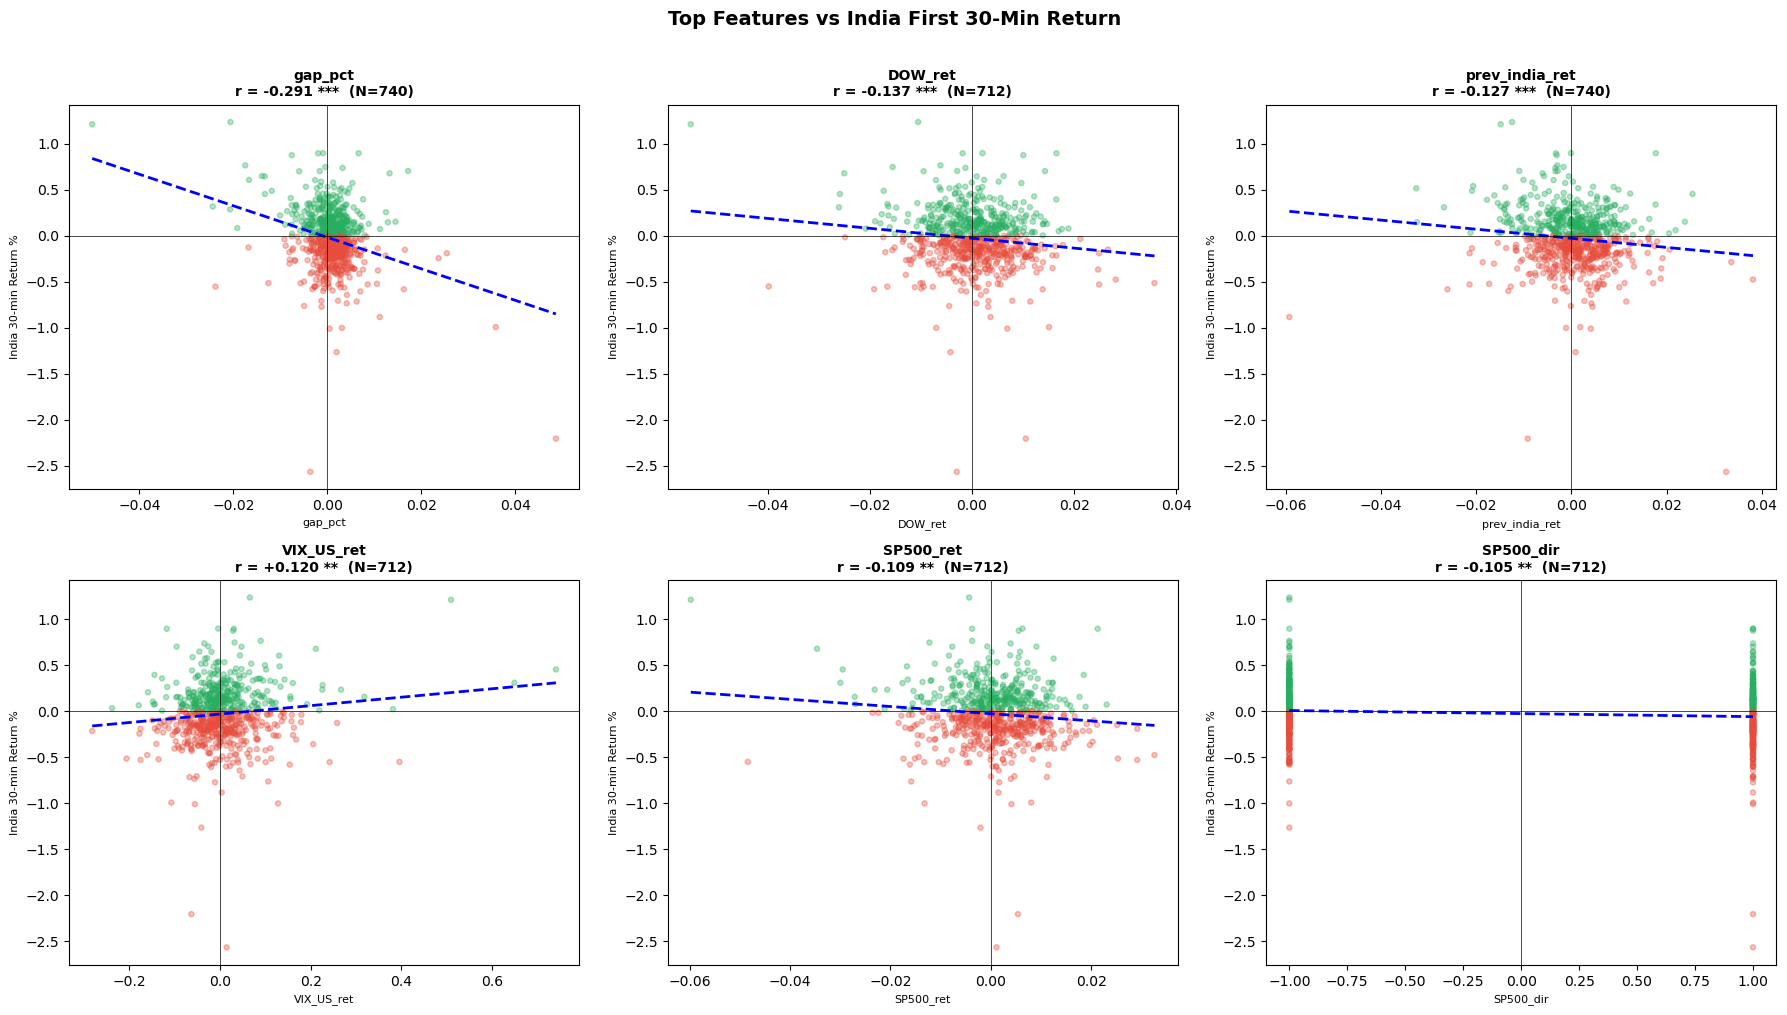

In [11]:
# Cell 10 — Scatter plots: top-6 features vs India 30-min return

top6 = corr_tbl.head(6)['Feature'].tolist()
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, feat in zip(axes.flat, top6):
    v = aligned[[feat,'ret_30','dir_30']].dropna()
    c = ['#27ae60' if d==1 else '#e74c3c' for d in v['dir_30']]
    ax.scatter(v[feat], v['ret_30']*100, c=c, alpha=0.35, s=14)
    z  = np.polyfit(v[feat], v['ret_30'], 1)
    xr = np.linspace(v[feat].min(), v[feat].max(), 200)
    ax.plot(xr, np.polyval(z, xr)*100, 'b--', lw=2)
    r, p = stats.pearsonr(v[feat], v['ret_30'])
    sig  = '***' if p<.001 else ('**' if p<.01 else ('*' if p<.05 else 'ns'))
    ax.set_title(f'{feat}\nr = {r:+.3f} {sig}  (N={len(v)})', fontweight='bold', fontsize=10)
    ax.set_xlabel(feat, fontsize=8)
    ax.set_ylabel('India 30-min Return %', fontsize=8)
    ax.axhline(0, color='k', lw=0.5)
    ax.axvline(0, color='k', lw=0.5)

plt.suptitle('Top Features vs India First 30-Min Return', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('v2_scatter_top_features.png', dpi=150, bbox_inches='tight')
plt.show()


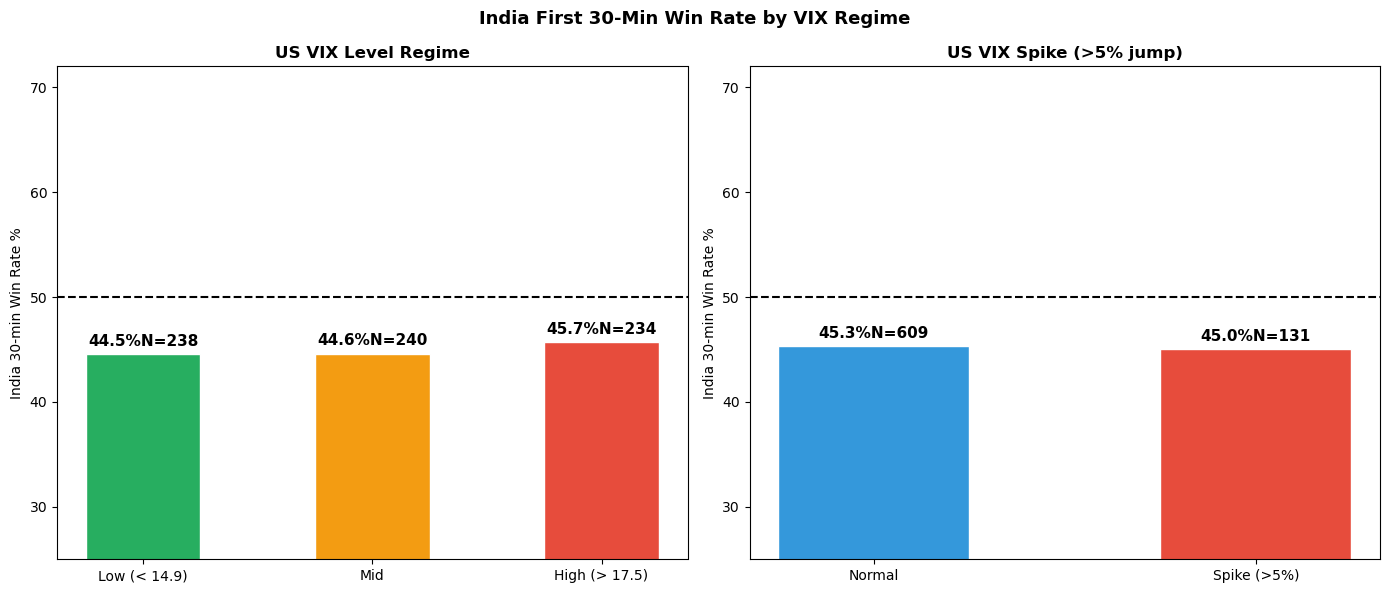

In [12]:
# Cell 11 — VIX level regime + VIX spike win-rate bar charts

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

def regime_bars(ax, col, title, split='tertile'):
    v = aligned[[col,'dir_30']].dropna()
    if len(v) < 30:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(title, fontweight='bold'); return
    if split == 'tertile':
        q33, q67 = v[col].quantile([0.33, 0.67])
        grps = [v[v[col]<=q33], v[(v[col]>q33)&(v[col]<=q67)], v[v[col]>q67]]
        lbls = [f'Low (< {q33:.1f})', 'Mid', f'High (> {q67:.1f})']
        clrs = ['#27ae60','#f39c12','#e74c3c']
    else:
        grps = [v[v[col]==0], v[v[col]==1]]
        lbls = ['Normal', 'Spike (>5%)']
        clrs = ['#3498db','#e74c3c']
    wrs  = [(g['dir_30']==1).mean()*100 for g in grps]
    ns   = [len(g) for g in grps]
    bars = ax.bar(lbls, wrs, color=clrs, edgecolor='white', width=0.5)
    ax.axhline(50, color='black', ls='--', lw=1.5)
    for bar, wr, n in zip(bars, wrs, ns):
        ax.text(bar.get_x()+bar.get_width()/2, wr+0.8,
                f'{wr:.1f}%N={n}', ha='center', fontsize=11, fontweight='bold')
    ax.set_ylim(25, 72)
    ax.set_ylabel('India 30-min Win Rate %')
    ax.set_title(title, fontweight='bold')

regime_bars(axes[0], 'VIX_US_level', 'US VIX Level Regime')     if 'VIX_US_level' in aligned.columns else axes[0].set_title('US VIX not available')

regime_bars(axes[1], 'VIX_US_spike', 'US VIX Spike (>5% jump)', split='binary')     if 'VIX_US_spike' in aligned.columns else axes[1].set_title('VIX Spike not available')

plt.suptitle('India First 30-Min Win Rate by VIX Regime', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('v2_vix_regime.png', dpi=150, bbox_inches='tight')
plt.show()


In [13]:
# Cell 12 — Composite signal
# weight = abs(r),  sign = sign(r)  ->  composite > 0 = Bullish FOR INDIA
# Thresholds: 33rd / 67th percentile (auto-scales to any score range)

sig_feats = corr_tbl[corr_tbl['p_30min'] < 0.10]['Feature'].tolist()
if not sig_feats:
    sig_feats = corr_tbl.head(6)['Feature'].tolist()
print(f'Composite uses {len(sig_feats)} features: {sig_feats}')

corr_signs, weights = {}, {}
for col in sig_feats:
    v = aligned[[col,'ret_30']].dropna()
    r, _ = stats.pearsonr(v[col], v['ret_30'])
    if abs(r) < 0.005: continue
    corr_signs[col] = float(np.sign(r))
    weights[col]    = abs(r)

w_tot       = sum(weights.values())
w_series    = pd.Series(weights) / w_tot
sign_series = pd.Series(corr_signs)

aligned['composite'] = (
    aligned[list(weights)].mul(sign_series).mul(w_series).sum(axis=1)
    / aligned[list(weights)].notna().sum(axis=1)
)

q33 = aligned['composite'].quantile(0.33)
q67 = aligned['composite'].quantile(0.67)
aligned['sentiment'] = pd.cut(aligned['composite'], bins=[-1, q33, q67, 1],
                               labels=['Bearish','Neutral','Bullish'], include_lowest=True)

print(f'Score range : {aligned["composite"].min():.4f}  to  {aligned["composite"].max():.4f}')
print(f'Thresholds  : Bearish < {q33:.4f}  |  Bullish > {q67:.4f}')
print()
for s in ['Bearish','Neutral','Bullish']:
    sub = aligned[aligned['sentiment']==s].dropna(subset=['dir_30'])
    if not len(sub): continue
    wr30 = (sub['dir_30']==1).mean()*100
    wr60 = (sub['dir_60']==1).mean()*100
    r30  = sub['ret_30'].mean()*100
    print(f'  {s:8s}  N={len(sub):3d}  WinRate30={wr30:.1f}%  AvgRet30={r30:+.3f}%  WinRate60={wr60:.1f}%')


Composite uses 15 features: ['gap_pct', 'DOW_ret', 'prev_india_ret', 'VIX_US_ret', 'SP500_ret', 'SP500_dir', 'SGX_dir', 'FTSE_ret', 'DAX_ret', 'NASDAQ_ret', 'DAX_dir', 'DOW_dir', 'NASDAQ_dir', 'SGX_ret', 'VIX_INDIA_ret']
Score range : -0.0211  to  0.0231
Thresholds  : Bearish < -0.0116  |  Bullish > 0.0081

  Bearish   N=244  WinRate30=36.9%  AvgRet30=-0.088%  WinRate60=41.0%
  Neutral   N=252  WinRate30=50.0%  AvgRet30=-0.016%  WinRate60=50.8%
  Bullish   N=244  WinRate30=48.8%  AvgRet30=+0.009%  WinRate60=48.4%


In [14]:
# Cell 14 — Morning signal (run before 9:15 AM IST every trading day)
# Fetches previous night's closes → computes composite score → prints bias
# NOTE: depends on weights, corr_signs, q33, q67 from Cell 12

def morning_signal():
    today = date.today()
    # end = today+1 so yfinance includes yesterday's close (end is exclusive)
    fetch_end = str(today + timedelta(days=1))
    fetch_start = str(today - timedelta(days=10))

    results = {}
    for name, ticker in {**PRICE_TICKERS, **VIX_TICKERS}.items():
        try:
            df = yf.download(ticker, start=fetch_start, end=fetch_end,
                             auto_adjust=True, progress=False)
            if isinstance(df.columns, pd.MultiIndex):
                df.columns = df.columns.get_level_values(0)
            c = df['Close'].dropna()
            if len(c) < 2:
                continue
            ret = float(c.iloc[-1] / c.iloc[-2] - 1)
            results[name] = {
                'ret'  : ret,
                'dir'  : int(np.sign(ret)),
                'close': float(c.iloc[-1]),
                'date' : str(c.index[-1])[:10],
            }
        except Exception:
            pass   # ticker unavailable (e.g. VIX_EU delisted) — skip silently

    # Composite score using weights learned in Cell 12
    sc, wt = [], []
    for col, wgt in weights.items():
        # Map feature column name back to market name
        mkt = col.replace('_ret','').replace('_level','').replace('_spike','')
        val = results.get(mkt, {}).get('ret', float('nan'))
        if val == val:   # not NaN
            sc.append(val * corr_signs[col] * wgt)
            wt.append(wgt)

    composite = sum(sc) / sum(wt) if wt else 0.0
    bias = 'Bullish' if composite > q67 else ('Bearish' if composite < q33 else 'Neutral')

    # ── Print table ───────────────────────────────────────────────────────────
    print(f'=== Morning Signal  {today} ===')
    print(f'{"Market":<14} {"Date":<12} {"Close":>10}  {"Return":>9}  Dir')
    print('-' * 56)
    for name, v in results.items():
        d = 'UP' if v['dir'] == 1 else ('DN' if v['dir'] == -1 else '--')
        print(f"{name:<14} {v['date']:<12} {v['close']:>10.2f}  {v['ret']:>+8.2%}  {d}")

    print(f'\nComposite score : {composite:+.4f}')
    print(f'Bias            : {bias}')

    sub = aligned[aligned['sentiment'] == bias].dropna(subset=['dir_30'])
    if len(sub):
        wr30 = (sub['dir_30'] == 1).mean() * 100
        wr60 = (sub['dir_60'] == 1).mean() * 100
        print(f'Historical      : 30-min win rate = {wr30:.1f}%  |  60-min = {wr60:.1f}%  (N={len(sub)})')

    print()
    print('Interpretation:')
    print('  Bearish bias = global markets up = India likely FADES in first hour (short/avoid long)')
    print('  Bullish bias = no strong signal upward (base rate ~45% up)')
    print('  Gap Down + US UP = strongest UP signal (see Cell 16 for pair/triplet detail)')

    return {'composite': composite, 'bias': bias, 'results': results}

signal = morning_signal()


HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: ^V2TX"}}}
$^V2TX: possibly delisted; no timezone found

1 Failed download:
['^V2TX']: possibly delisted; no timezone found


=== Morning Signal  2026-04-03 ===
Market         Date              Close     Return  Dir
--------------------------------------------------------
SP500          2026-04-02      6582.69    +0.11%  UP
NASDAQ         2026-04-02     21879.18    +0.18%  UP
DOW            2026-04-02     46504.67    -0.13%  DN
NIKKEI         2026-04-01     53739.68    +5.24%  UP
DAX            2026-04-02     23168.08    -0.56%  DN
HANGSENG       2026-04-01     25294.03    +2.04%  UP
FTSE           2026-04-02     10436.29    +0.69%  UP
SGX            2026-04-02     53325.00    -1.71%  DN
VIX_US         2026-04-02        23.87    -2.73%  DN

Composite score : -0.0030
Bias            : Neutral
Historical      : 30-min win rate = 50.0%  |  60-min = 50.8%  (N=252)

Interpretation:
  Bearish bias = global markets up = India likely FADES in first hour (short/avoid long)
  Bullish bias = no strong signal upward (base rate ~45% up)
  Gap Down + US UP = strongest UP signal (see Cell 16 for pair/triplet detail)


In [15]:
# Cell 15 — Export all results

aligned.to_csv('v2_aligned_dataset.csv')
corr_tbl.to_csv('v2_correlation_table.csv', index=False)

summary_rows = []
for s in ['Bearish','Neutral','Bullish']:
    sub = aligned[aligned['sentiment']==s].dropna(subset=['dir_30'])
    if not len(sub): continue
    summary_rows.append({'Sentiment': s, 'N': len(sub),
        'WinRate_30min': f'{(sub["dir_30"]==1).mean()*100:.1f}%',
        'AvgRet_30min' : f'{sub["ret_30"].mean()*100:+.3f}%',
        'WinRate_60min': f'{(sub["dir_60"]==1).mean()*100:.1f}%',
        'AvgRet_60min' : f'{sub["ret_60"].mean()*100:+.3f}%'})
pd.DataFrame(summary_rows).to_csv('v2_sentiment_summary.csv', index=False)

print('Exported files:')
for f in ['v2_aligned_dataset.csv','v2_correlation_table.csv','v2_sentiment_summary.csv',
          'v2_scatter_top_features.png','v2_vix_regime.png','v2_winrate_chart.png']:
    exists = os.path.exists(f)
    size   = os.path.getsize(f) if exists else 0
    status = f'{size:,} bytes' if exists else 'not yet (run earlier cells)'
    print(f'  {f:<40s}  {status}')


Exported files:
  v2_aligned_dataset.csv                    409,397 bytes
  v2_correlation_table.csv                  2,395 bytes
  v2_sentiment_summary.csv                  190 bytes
  v2_scatter_top_features.png               496,914 bytes
  v2_vix_regime.png                         69,998 bytes
  v2_winrate_chart.png                      131,609 bytes


In [16]:
# Cell 16 — Signal Combinations: Pairs + Triplets + Quadruplets
# Statistical significance via one-sided binomial test vs base rate
# Verdict: RELIABLE = p<0.05 AND N>=40 | SUGGESTIVE = p<0.10 AND N>=20 | else WEAK
#
# Signals defined:
#   gap_up       : India opens >0.15% above prev close          (gap absorbed = reversal)
#   gap_down     : India opens >0.15% below prev close          (bounce likely)
#   gap_large    : Gap up >0.5%                                 (strong overextension)
#   prev_up      : NIFTY closed GREEN yesterday (full-day ret)  (mean reversion)
#   prev_down    : NIFTY closed RED yesterday
#   us_up        : S&P 500 closed UP previous night
#   us_down      : S&P 500 closed DOWN previous night
#   sgx_up       : SGX (Nikkei USD futures) closed UP           (overnight Nifty proxy)
#   sgx_down     : SGX closed DOWN
#   dax_up       : DAX (Europe) closed UP
#   vix_up       : VIX rose >3% (fear increasing)
#   vix_down     : VIX fell >3% (complacency — gap-ups often fade harder)
#   vix_spike    : VIX rose >10% (panic day)

from itertools import combinations
from scipy.stats import norm as _norm

df = aligned.copy()

# ── Binary signal columns ─────────────────────────────────────────────────────
df['gap_up']    = (df['gap_pct'] >  0.0015).astype(int)
df['gap_down']  = (df['gap_pct'] < -0.0015).astype(int)
df['gap_large'] = (df['gap_pct'] >  0.0050).astype(int)
df['prev_up']   = (df['prev_india_ret'] >  0).astype(int)
df['prev_down'] = (df['prev_india_ret'] <  0).astype(int)
df['us_up']     = (df['SP500_dir']  ==  1).astype(int)
df['us_down']   = (df['SP500_dir']  == -1).astype(int)
df['sgx_up']    = (df['SGX_dir']    ==  1).astype(int)
df['sgx_down']  = (df['SGX_dir']    == -1).astype(int)
df['dax_up']    = (df['DAX_dir']    ==  1).astype(int)
df['vix_up']    = (df['VIX_US_ret'] >  0.03).astype(int)
df['vix_down']  = (df['VIX_US_ret'] < -0.03).astype(int)
df['vix_spike'] = (df['VIX_US_ret'] >  0.10).astype(int)

df = df[df['dir_30'].isin([1, -1])].copy()
df['india_down'] = (df['dir_30'] == -1).astype(int)
df['india_up']   = (df['dir_30'] ==  1).astype(int)

N_TOTAL   = len(df)
BASE_RATE = df['india_down'].mean()

SIGNALS = {
    'Gap Up'         : 'gap_up',
    'Gap Up Strong'  : 'gap_large',
    'Gap Down'       : 'gap_down',
    'Prev India UP'  : 'prev_up',
    'Prev India DOWN': 'prev_down',
    'US UP'          : 'us_up',
    'US DOWN'        : 'us_down',
    'SGX UP'         : 'sgx_up',
    'SGX DOWN'       : 'sgx_down',
    'DAX UP'         : 'dax_up',
    'VIX Rising'     : 'vix_up',
    'VIX Falling'    : 'vix_down',
    'VIX Spike'      : 'vix_spike',
}
sig_list = list(SIGNALS.items())

print(f'Base rate P(India 30-min DOWN) = {BASE_RATE*100:.1f}%   N = {N_TOTAL}')
print(f'Signals defined: {len(SIGNALS)}')
print()

def wilson_ci(k, n, z=1.96):
    p = k / n
    denom = 1 + z**2 / n
    centre = (p + z**2 / (2*n)) / denom
    margin = z * (p*(1-p)/n + z**2/(4*n**2))**0.5 / denom
    return max(0, centre - margin)*100, min(1, centre + margin)*100

def analyze_combo(sub):
    n = len(sub)
    if n < 10:
        return None
    k_dn = int(sub['india_down'].sum())
    k_up = int(sub['india_up'].sum())
    p_dn = k_dn / n
    p_up = k_up / n
    edge = p_dn - BASE_RATE

    # One-sided binomial test: is observed proportion significantly different from base?
    if edge >= 0:
        from scipy.stats import binomtest
        pval = binomtest(k_dn, n, BASE_RATE, alternative='greater').pvalue
        direction = 'DOWN'
    else:
        from scipy.stats import binomtest
        pval = binomtest(k_up, n, 1 - BASE_RATE, alternative='greater').pvalue
        direction = 'UP'

    ci_lo, ci_hi = wilson_ci(k_dn, n)
    sig = ('***' if pval < 0.001 else
           '**'  if pval < 0.01  else
           '*'   if pval < 0.05  else 'ns')

    verdict = ('RELIABLE'    if pval < 0.05 and n >= 40 else
               'SUGGESTIVE'  if pval < 0.10 and n >= 20 else
               'WEAK/SPARSE')

    return {
        'N'        : n,
        'Freq_pct' : round(n / N_TOTAL * 100, 1),
        'P_Down'   : round(p_dn * 100, 1),
        'P_Up'     : round(p_up * 100, 1),
        'Edge_pp'  : round(edge * 100, 1),
        'CI_lo'    : round(ci_lo, 1),
        'CI_hi'    : round(ci_hi, 1),
        'p_val'    : round(pval, 4),
        'Sig'      : sig,
        'Direction': direction,
        'Verdict'  : verdict,
    }

# ── Run all combination levels ────────────────────────────────────────────────
all_results = []

for level, r in [(1, 1), (2, 2), (3, 3), (4, 4)]:
    count = 0
    for combo in combinations(sig_list, level):
        labels = [c[0] for c in combo]
        cols   = [c[1] for c in combo]
        mask = (df[cols[0]] == 1)
        for c in cols[1:]:
            mask = mask & (df[c] == 1)
        sub = df[mask]
        res = analyze_combo(sub)
        if res:
            res['Level']  = level
            res['Signal'] = ' + '.join(labels)
            all_results.append(res)
            count += 1
    print(f'Level {level} combinations computed: {count}')

results_df = pd.DataFrame(all_results)

# ── Print RELIABLE signals only, by level ─────────────────────────────────────
print()
print('=' * 105)
print('ALL RELIABLE SIGNALS  (p < 0.05  AND  N >= 40)  sorted by P(Down)')
print('=' * 105)
print(f'  {"Signal":<58} {"Lvl":>3} {"N":>5} {"Freq%":>6} {"P(Dn)":>7} {"P(Up)":>7} {"Edge":>7} {"95% CI":>18} {"p-val":>8} {"Sig":>4}')
print('-' * 105)

reliable = results_df[results_df['Verdict'] == 'RELIABLE'].sort_values('P_Down', ascending=False)
for _, r in reliable.iterrows():
    ci = f"[{r['CI_lo']:.1f},{r['CI_hi']:.1f}]"
    print(f"  {r['Signal']:<58} {int(r['Level']):>3} {int(r['N']):>5} {r['Freq_pct']:>5.1f}% "
          f"{r['P_Down']:>6.1f}% {r['P_Up']:>6.1f}% {r['Edge_pp']:>+6.1f}pp {ci:>18} "
          f"{r['p_val']:>8.4f} {r['Sig']:>4}")

print()
counts = results_df.groupby(['Level','Verdict']).size().unstack(fill_value=0)
print('Summary by level:')
print(counts)

# Save
results_df.to_csv('v2_signal_combinations.csv', index=False)
reliable.to_csv('v2_reliable_signals.csv', index=False)
print('\nSaved: v2_signal_combinations.csv  |  v2_reliable_signals.csv')


Base rate P(India 30-min DOWN) = 54.7%   N = 739
Signals defined: 13

Level 1 combinations computed: 13
Level 2 combinations computed: 66
Level 3 combinations computed: 151
Level 4 combinations computed: 144

ALL RELIABLE SIGNALS  (p < 0.05  AND  N >= 40)  sorted by P(Down)
  Signal                                                     Lvl     N  Freq%   P(Dn)   P(Up)    Edge             95% CI    p-val  Sig
---------------------------------------------------------------------------------------------------------
  Gap Up + Prev India DOWN + US UP + SGX UP                    4    67   9.1%   74.6%   25.4%  +20.0pp        [63.1,83.5]   0.0006  ***
  Gap Up + Prev India DOWN + SGX UP + DAX UP                   4    54   7.3%   74.1%   25.9%  +19.4pp        [61.1,83.9]   0.0027   **
  Gap Up + Prev India DOWN + SGX UP + VIX Falling              4    44   6.0%   72.7%   27.3%  +18.1pp        [58.2,83.7]   0.0109    *
  Gap Up + Prev India DOWN + SGX UP                            3    73   9.9